# 🎵 Projet Audio: Reconnaissance des Émotions

Ce projet a pour but de structurer, prétraiter et analyser des données audios provenant de 4 datasets différents (RAVDESS, CREMA-D, SAVEE, TESS).

In [ ]:
!pip install librosa matplotlib numpy tensorflow sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [ ]:
# On crée un dossier local
!mkdir -p /content/dataset_local

print("📦 Copie du dataset en cours vers l'instance locale...")
# Utilise cp -r pour copier les dossiers.
# Si tu as un fichier .zip, utilise : !unzip -q /chemin/vers/ton/drive/data.zip -d /content/dataset_local
!cp -r "/content/drive/MyDrive/Projet_Audio/Projet_Audio/Datasets/." /content/dataset_local/

print("✅ Copie terminée sur l'instance locale.")

📦 Copie du dataset en cours vers l'instance locale...
✅ Copie terminée sur l'instance locale.


## 1. Mappage et Définition des Sentiments

- **0**: Neutre, **1**: Joie, **2**: Tristesse, **3**: Colère, **4**: Peur, **5**: Dégoût, **6**: Surprise, **7**: Calm

In [ ]:
DATASET_PATH = r"/content/dataset_local"
RAVDESS_PATH = os.path.join(DATASET_PATH, "RAVDESS")
CREMAD_PATH = os.path.join(DATASET_PATH, "CREMA-D")
SAVEE_PATH = os.path.join(DATASET_PATH, "SAVEE")
TESS_PATH = os.path.join(DATASET_PATH, "TESS")



In [ ]:
emotion_map_str_to_int = {
    'Neutral': 0, 'Happy': 1, 'Sad': 2,
    'Angry': 3, 'Fear': 4, 'Disgust': 5,
    'Surprise': 6, "Calm": 7
}

## 2. Extraction et Consolidation des Datasets

Nous extrayons le chemin relatif, absolu et le sentiment pour chaque fichier audio.

In [ ]:
# --- MAPPINGS DES ÉMOTIONS ---
ravdess_map = {'01':'Neutral', '02':'Calm', '03':'Happy', '04':'Sad', '05':'Angry', '06':'Fear', '07':'Disgust', '08':'Surprise'}
crema_map = {'NEU':'Neutral', 'HAP':'Happy', 'SAD':'Sad', 'ANG':'Angry', 'FEA':'Fear', 'DIS':'Disgust'}
savee_map = {'n':'Neutral', 'h':'Happy', 'sa':'Sad', 'a':'Angry', 'f':'Fear', 'd':'Disgust', 'su':'Surprise'}
# TESS : On gère les variantes de ta photo
tess_map = {
    'neutral': 'Neutral', 'happy': 'Happy', 'sad': 'Sad',
    'angry': 'Angry', 'fear': 'Fear', 'disgust': 'Disgust',
    'ps': 'Surprise', 'pleasant_surprise': 'Surprise', 'pleasant_surprised': 'Surprise'
}

# --- FONCTIONS DE PARSING (Optimisées pour les Threads) ---

def parse_ravdess(fp):
    parts = os.path.basename(fp).split('-')
    if len(parts) >= 3 and parts[2] in ravdess_map:
        emo = ravdess_map[parts[2]]
        return {'Chemin_Relatif': os.path.relpath(fp, DATASET_PATH), 'Chemin_Absolu': fp, 'Dataset': 'RAVDESS', 'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

def parse_cremad(fp):
    parts = os.path.basename(fp).split('_')
    if len(parts) >= 3 and parts[2] in crema_map:
        emo = crema_map[parts[2]]
        return {'Chemin_Relatif': os.path.relpath(fp, DATASET_PATH), 'Chemin_Absolu': fp, 'Dataset': 'CREMA-D', 'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

def parse_tess(fp):
    fn_lower = fp.lower()
    for key, emo in tess_map.items():
        if key in fn_lower: # Détection par mot-clé dans le chemin (plus robuste pour tes dossiers)
            return {'Chemin_Relatif': os.path.relpath(fp, DATASET_PATH), 'Chemin_Absolu': fp, 'Dataset': 'TESS', 'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

def parse_savee(fp):
    parts = os.path.basename(fp).split('_')
    if len(parts) == 2:
        emo_code = ''.join([c for c in parts[1] if not c.isdigit()]).replace('.wav', '')
        if emo_code in savee_map:
            emo = savee_map[emo_code]
            return {'Chemin_Relatif': os.path.relpath(fp, DATASET_PATH), 'Chemin_Absolu': fp, 'Dataset': 'SAVEE', 'Sentiment': emo, 'Numero_Sentiment': emotion_map_str_to_int[emo]}
    return None

# --- EXÉCUTION PRINCIPALE ---

all_data = []

# Liste des configurations (Fonction de parsing, Liste des fichiers, Nom pour la barre)
tasks = [
    (parse_ravdess, [os.path.join(r, f) for r, _, fs in os.walk(RAVDESS_PATH) for f in fs if f.endswith('.wav')], "RAVDESS"),
    (parse_cremad, glob.glob(os.path.join(CREMAD_PATH, '*.wav')), "CREMA-D"),
    (parse_tess, [os.path.join(r, f) for r, _, fs in os.walk(TESS_PATH) for f in fs if f.endswith('.wav')], "TESS"),
    (parse_savee, glob.glob(os.path.join(SAVEE_PATH, '*.wav')), "SAVEE")
]

print("🚀 Démarrage de l'indexation parallélisée...")

for parse_func, files, name in tasks:
    if not files:
        print(f"⚠️ Aucun fichier trouvé pour {name}. Vérifiez le chemin.")
        continue

    with ThreadPoolExecutor() as executor:
        # executor.map distribue le travail sur plusieurs coeurs CPU
        results = list(tqdm(executor.map(parse_func, files), total=len(files), desc=f"Chargement {name}"))
        # On ajoute seulement les résultats qui ne sont pas None
        all_data.extend([r for r in results if r is not None])

# Création du DataFrame final
df_audio = pd.DataFrame(all_data)

print(f"\n✅ Terminé ! Total de fichiers consolidés : {len(df_audio)}")
if not df_audio.empty:
    display(df_audio.sample(min(5, len(df_audio)))) # Affiche un échantillon aléatoire

🚀 Démarrage de l'indexation parallélisée...



Chargement RAVDESS: 100%|██████████| 1440/1440 [00:00<00:00, 348758.39it/s]

Chargement CREMA-D: 100%|██████████| 7442/7442 [00:00<00:00, 325437.48it/s]

Chargement TESS: 100%|██████████| 2800/2800 [00:00<00:00, 393633.36it/s]

Chargement SAVEE: 100%|██████████| 480/480 [00:00<00:00, 365185.18it/s]


✅ Terminé ! Total de fichiers consolidés : 12162


,Chemin_Relatif,Chemin_Absolu,Dataset,Sentiment,Numero_Sentiment
7097,CREMA-D/1070_DFA_HAP_XX.wav,/content/dataset_local/CREMA-D/1070_DFA_HAP_XX...,CREMA-D,Happy,1
2459,CREMA-D/1037_IWL_DIS_XX.wav,/content/dataset_local/CREMA-D/1037_IWL_DIS_XX...,CREMA-D,Disgust,5
9113,TESS/YAF_pleasant_surprised/YAF_back_ps.wav,/content/dataset_local/TESS/YAF_pleasant_surpr...,TESS,Surprise,6
6011,CREMA-D/1061_WSI_SAD_XX.wav,/content/dataset_local/CREMA-D/1061_WSI_SAD_XX...,CREMA-D,Sad,2
9605,TESS/OAF_Pleasant_surprise/OAF_reach_ps.wav,/content/dataset_local/TESS/OAF_Pleasant_surpr...,TESS,Surprise,6


## 3. Analyse Exploratoire et Visualisations
Distribution des fichiers au travers des différents datasets et sentiments.

/tmp/ipykernel_4231/1090336640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df_audio, x='Dataset', palette='viridis', order=df_audio['Dataset'].value_counts().index)


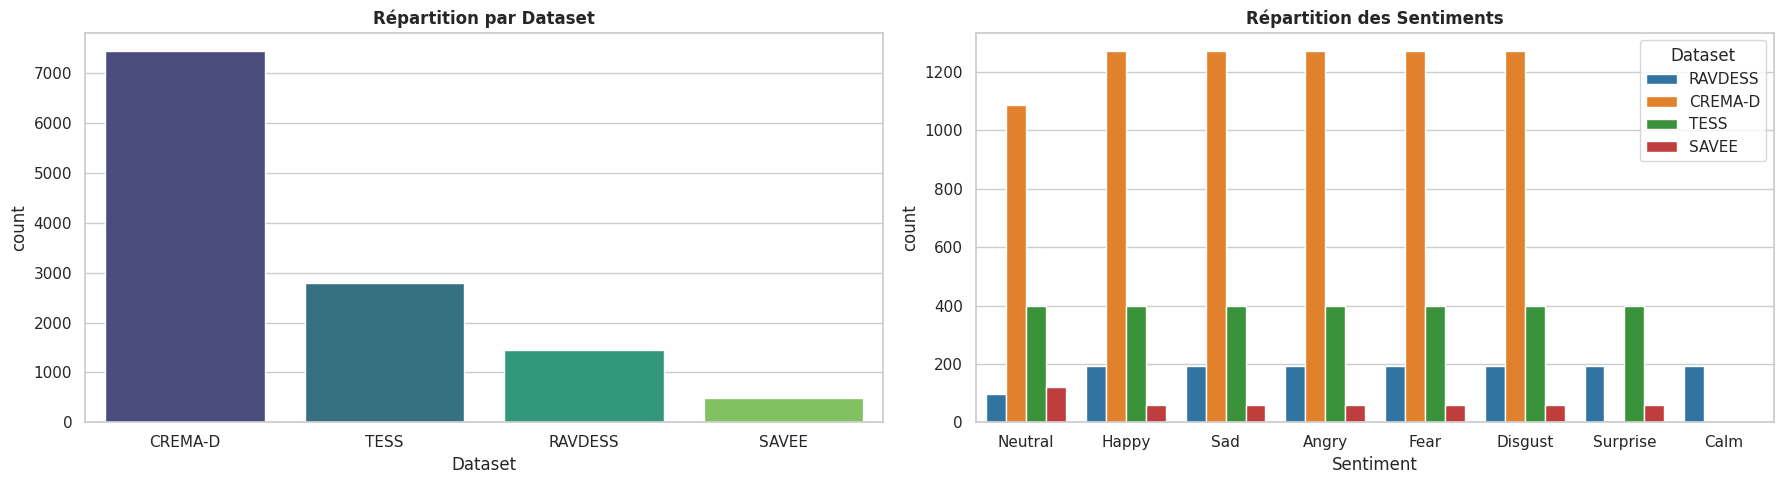

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.countplot(ax=axes[0], data=df_audio, x='Dataset', palette='viridis', order=df_audio['Dataset'].value_counts().index)
axes[0].set_title("Répartition par Dataset", fontweight='bold')

sns.countplot(ax=axes[1], data=df_audio, x='Sentiment', hue='Dataset', palette='tab10', order=list(emotion_map_str_to_int.keys()))
axes[1].set_title("Répartition des Sentiments", fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Visualisation d'Audios et Spectrogrammes de Mel

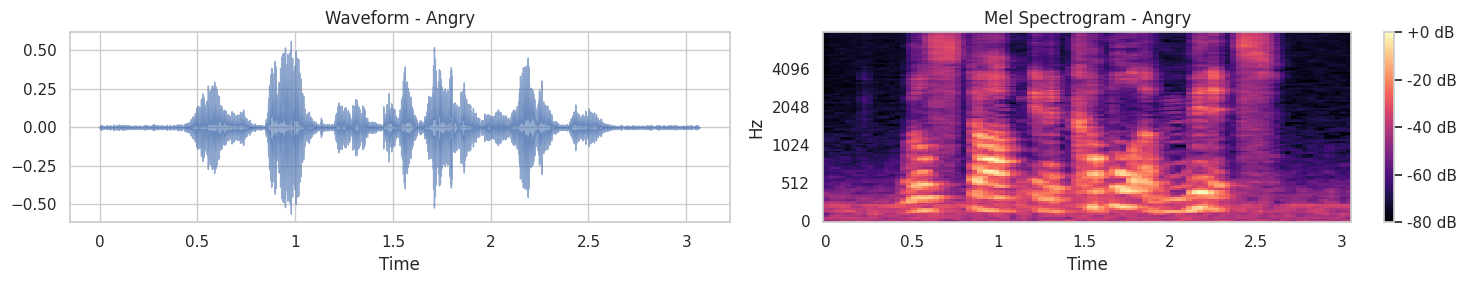

In [ ]:
def plot_waveform_and_spectrogram(path, emotion):
    plt.figure(figsize=(15, 3))
    y, sr = librosa.load(path, sr=None)

    plt.subplot(1, 2, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f"Waveform - {emotion}")

    plt.subplot(1, 2, 2)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f"Mel Spectrogram - {emotion}")

    plt.tight_layout()
    plt.show()

# Exemple aléatoire d'un sentiment
sample_row = df_audio.sample(1).iloc[0]
plot_waveform_and_spectrogram(sample_row['Chemin_Absolu'], sample_row['Sentiment'])

In [ ]:
import librosa
import numpy as np

def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

def identity(data):
    return data

In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.5 MB/s eta 0:00:00


  3%|▎         | 371/12162 [41:26<21:57:04,  6.70s/it]


## 5.Extraction des features et training du modèle

In [ ]:
import numpy as np
import librosa
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, LSTM, Conv1D, GlobalAveragePooling1D, Dense, Dropout, BatchNormalization, MaxPooling1D
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras import callbacks
import joblib

# ==========================================
# 1. FONCTION D'EXTRACTION V3.2 (DOUBLÉE)
# ==========================================
def extract_features_v3(path, label, augment=False):
    try:
        # Chargement (2.5 secondes)
        data, sr = librosa.load(path, sr=22050, duration=2.5)
        target_length = 55125
        if len(data) < target_length:
            data = np.pad(data, (0, target_length - len(data)), mode='constant')
        else:
            data = data[:target_length]

        # Application de l'augmentation si demandée
        if augment:
            choice = np.random.choice(['noise', 'stretch', 'pitch', 'shift'])
            if choice == 'noise':
                noise_amp = 0.005 * np.random.uniform() * np.amax(data)
                data = data + noise_amp * np.random.normal(size=data.shape[0])
            elif choice == 'stretch':
                data = librosa.effects.time_stretch(data, rate=np.random.uniform(0.8, 1.2))
                data = np.pad(data, (0, max(0, target_length - len(data))), mode='constant')[:target_length]
            elif choice == 'pitch':
                data = librosa.effects.pitch_shift(data, sr=sr, n_steps=np.random.uniform(-2, 2))
            elif choice == 'shift':
                data = np.roll(data, int(sr/5))

        # Extraction des caractéristiques (116 au total)
        mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T
        chroma = librosa.feature.chroma_stft(y=data, sr=sr).T
        mel = librosa.power_to_db(librosa.feature.melspectrogram(y=data, sr=sr, n_mels=64)).T

        combined = np.hstack([mfcc, chroma, mel]) # Shape (Time, 116)

        # Segmentation en 10 blocs temporels pour le LSTM
        segments = np.array_split(combined, 10, axis=0)
        return np.array([np.mean(seg, axis=0) for seg in segments]), label

    except Exception:
        return None, None

# ==========================================
# 2. GÉNÉRATION DU DATASET (PURE + AUGMENTED)
# ==========================================
X_final = []
Y_final = []

print("🏗️ Création du dataset doublé (cette étape peut être longue)...")
for _, row in tqdm(df_audio.iterrows(), total=len(df_audio)):
    # Version Pure
    f_orig, l_orig = extract_features_v3(row['Chemin_Absolu'], row['Numero_Sentiment'], augment=False)
    # Version Augmentée
    f_aug, l_aug = extract_features_v3(row['Chemin_Absolu'], row['Numero_Sentiment'], augment=True)

    if f_orig is not None and f_aug is not None:
        X_final.extend([f_orig, f_aug])
        Y_final.extend([l_orig, l_aug])

X_final = np.array(X_final)
Y_final = np.array(Y_final)

# ==========================================
# 3. NORMALISATION ET PRÉPARATION
# ==========================================
n_samples, n_steps, n_feat = X_final.shape
X_reshaped = X_final.reshape(-1, n_feat)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped).reshape(n_samples, n_steps, n_feat)

Y_encoded = to_categorical(Y_final, num_classes=8)

# Split 80/20
x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y_encoded, test_size=0.2, random_state=42)

# Ajout du canal pour le CNN
x_train_v3 = np.expand_dims(x_train, axis=3)
x_test_v3 = np.expand_dims(x_test, axis=3)

# ==========================================
# 4. ARCHITECTURE DU MODÈLE (V3.2 LIGHT)
# ==========================================
def create_model_v3_final(input_shape):
    model = Sequential()

    # Bloc CNN avec Global Pooling (plus robuste)
    model.add(TimeDistributed(Conv1D(64, 3, padding='same', activation='relu'), input_shape=input_shape))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(MaxPooling1D(pool_size=2)))

    model.add(TimeDistributed(Conv1D(128, 3, padding='same', activation='relu')))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(GlobalAveragePooling1D()))

    # Bloc LSTM
    model.add(LSTM(128, return_sequences=False))
    model.add(Dropout(0.5))

    # Dense Finale
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(8, activation='softmax'))

    return model

model = create_model_v3_final((10, 116, 1))

# Compilation avec Label Smoothing (0.1)
model.compile(
    optimizer='adam',
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# ==========================================
# 5. ENTRAÎNEMENT
# ==========================================
rlrp = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.000005, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)

print("🏁 Entraînement final lancé sur dataset doublé...")
history = model.fit(
    x_train_v3, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(x_test_v3, y_test),
    callbacks=[rlrp, early_stop],
    shuffle=True
)

# Sauvegarde
model.save('/content/drive/MyDrive/Projet_Audio/Projet_Audio/cnn_lstm_v3_final.h5')
print("✅ Modèle sauvegardé avec succès.")

🏗️ Création du dataset doublé (cette étape peut être longue)...


 44%|████▍     | 5390/12162 [07:25<14:45,  7.65it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████| 12162/12162 [16:41<00:00, 12.15it/s]
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


🏁 Entraînement final lancé sur dataset doublé...
Epoch 1/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.3478 - loss: 1.7594 - val_accuracy: 0.4569 - val_loss: 1.5378 - learning_rate: 0.0010
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.4577 - loss: 1.5628 - val_accuracy: 0.4989 - val_loss: 1.4680 - learning_rate: 0.0010
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.5039 - loss: 1.4825 - val_accuracy: 0.5488 - val_loss: 1.3703 - learning_rate: 0.0010
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5371 - loss: 1.4294 - val_accuracy: 0.5464 - val_loss: 1.3740 - learning_rate: 0.0010
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.5489 - loss: 1.3979 - val_accuracy: 0.5597 - val_loss: 1.3569 - learning_rate: 0.0010
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5634 - loss: 1.3800 - val_accuracy: 0.5782 - val_loss: 1.3245 - learning_rate: 0.0010
Epoch 7/100
609/609 ━

✅ Modèle sauvegardé avec succès.


## 6. Résultats et Visualisations

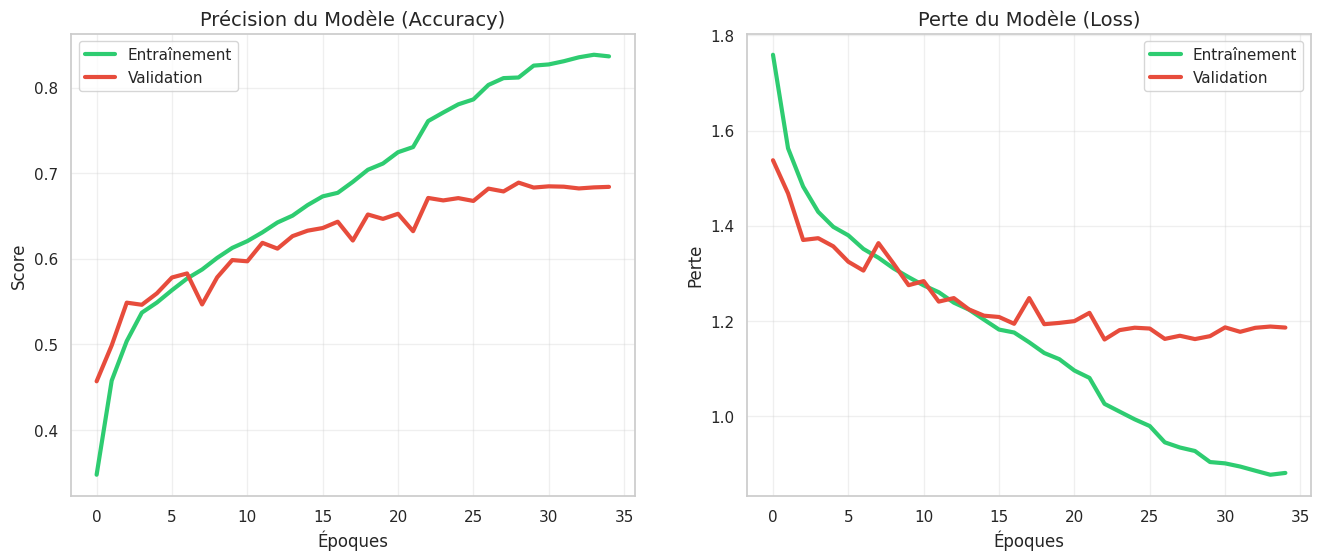

✅ Courbes sauvegardées sous : /content/drive/MyDrive/Projet_Audio/Projet_Audio/courbes_entrainement_v3.png
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


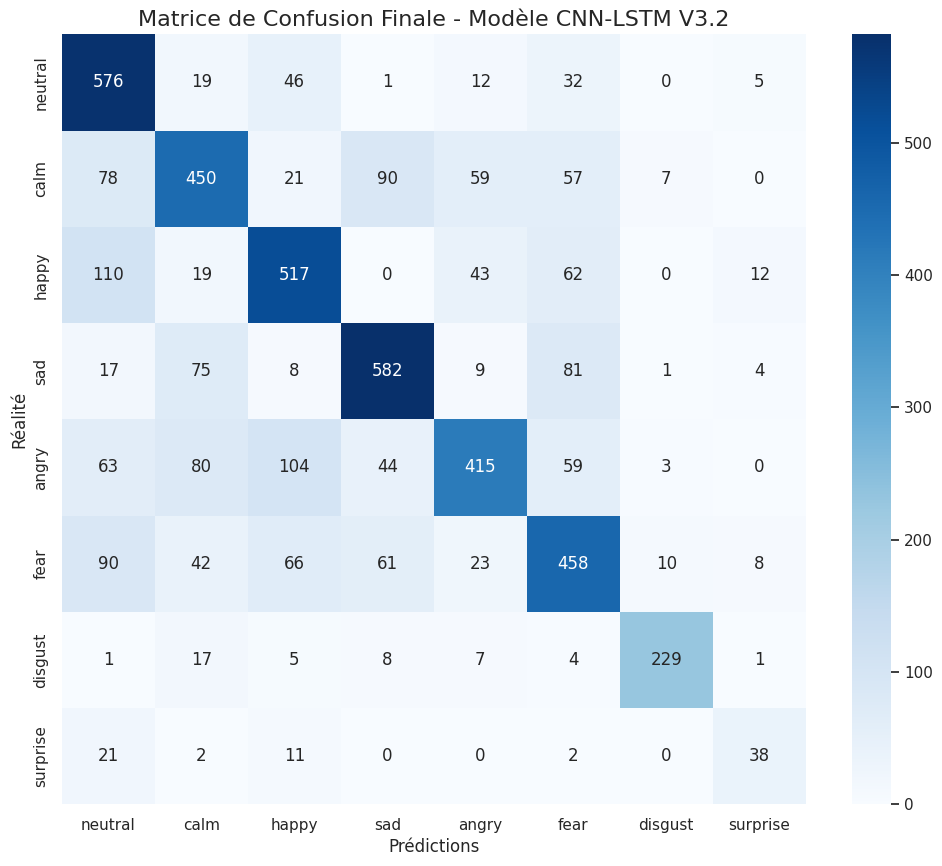

✅ Matrice sauvegardée sous : /content/drive/MyDrive/Projet_Audio/Projet_Audio/matrice_confusion_v3.png
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


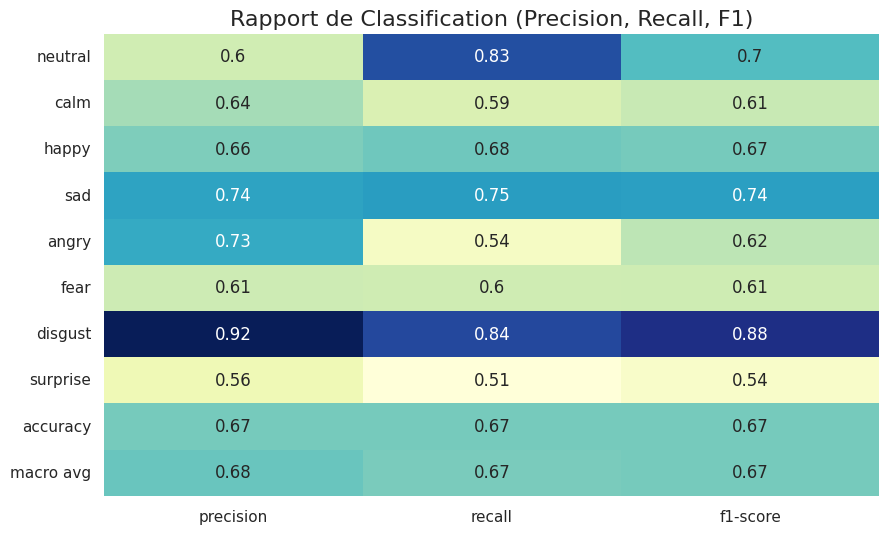

✅ Rapport sauvegardé sous : /content/drive/MyDrive/Projet_Audio/Projet_Audio/rapport_metrics_v3.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Chemin de sauvegarde sur ton Drive
save_path = '/content/drive/MyDrive/Projet_Audio/Projet_Audio/'

# ==========================================
# 1. SAUVEGARDE DES COURBES (LOSS & ACCURACY)
# ==========================================
def save_training_curves(history, path):
    plt.figure(figsize=(16, 6))

    # Précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entraînement', color='#2ecc71', lw=3)
    plt.plot(history.history['val_accuracy'], label='Validation', color='#e74c3c', lw=3)
    plt.title('Précision du Modèle (Accuracy)', fontsize=14)
    plt.xlabel('Époques')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entraînement', color='#2ecc71', lw=3)
    plt.plot(history.history['val_loss'], label='Validation', color='#e74c3c', lw=3)
    plt.title('Perte du Modèle (Loss)', fontsize=14)
    plt.xlabel('Époques')
    plt.ylabel('Perte')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(path + 'courbes_entrainement_v3.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Courbes sauvegardées sous : {path}courbes_entrainement_v3.png")

# ==========================================
# 2. SAUVEGARDE DE LA MATRICE DE CONFUSION
# ==========================================
def save_confusion_matrix(model, x_test, y_test, labels, path):
    y_pred = np.argmax(model.predict(x_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 12})
    plt.title('Matrice de Confusion Finale - Modèle CNN-LSTM V3.2', fontsize=16)
    plt.xlabel('Prédictions', fontsize=12)
    plt.ylabel('Réalité', fontsize=12)

    plt.savefig(path + 'matrice_confusion_v3.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Matrice sauvegardée sous : {path}matrice_confusion_v3.png")

# ==========================================
# 3. SAUVEGARDE DU RAPPORT DE MÉTRIQUES EN IMAGE
# ==========================================
def save_classification_report(y_true, y_pred, labels, path):
    report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    plt.figure(figsize=(10, 6))
    sns.heatmap(report_df.iloc[:-1, :].iloc[:, :-1], annot=True, cmap='YlGnBu', cbar=False)
    plt.title('Rapport de Classification (Precision, Recall, F1)', fontsize=16)

    plt.savefig(path + 'rapport_metrics_v3.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Rapport sauvegardé sous : {path}rapport_metrics_v3.png")

# --- EXÉCUTION ---
emotion_labels = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise']

# Appel des fonctions
save_training_curves(history, save_path)
save_confusion_matrix(model, x_test_v3, y_test, emotion_labels, save_path)

# Pour le rapport, on génère d'abord les prédictions
y_pred_final = np.argmax(model.predict(x_test_v3), axis=1)
y_true_final = np.argmax(y_test, axis=1)
save_classification_report(y_true_final, y_pred_final, emotion_labels, save_path)